# 05a — Vizualizacija: Intermediate Layer Activations

Cilj ovog notebook-a je da razumemo kako baseline model (VGG-6, iz `02_baseline_cnn.ipynb`) "vidi" sliku, ne samo da li je tačno klasifikuje. Umesto da gledamo samo finalni izlaz (cat/dog), izvlačimo međurezultate — šta svaki konvolucioni sloj proizvede kad kroz njega prođe jedna slika (Lin, 2020, sekcija 5.1).

Koristi se sačuvan model iz koraka 2 (`vgg6_baseline_regularized.keras`).


## 1. Setup i učitavanje modela

Montiramo Drive i učitavamo vec istreniran model.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
drive.mount("/content/drive")

MODEL_PATH = "/content/drive/MyDrive/MU-projekat/models/vgg6_baseline_regularized.keras"
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

Mounted at /content/drive


Model: "vgg6_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,173,828 (99.85 MB)

 Trainable params: 13,086,913 (49.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,086,915 (49.92 MB)

## 2. Primer: pas

Biramo prvu psa-sliku iz test skupa i pripremamo je identično kao tokom treninga (224×224, skaliranje piksela na [0,1]).


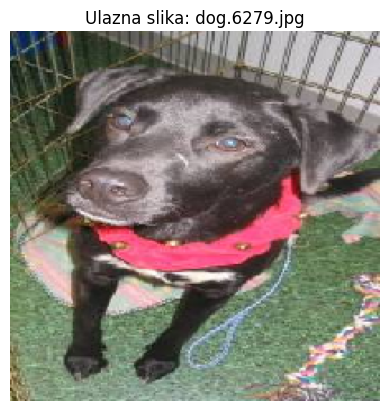

In [ ]:
# rad (Lin, 2020) bira sliku psa za ovu demonstraciju - radimo isto
split_df = pd.read_csv("/content/drive/MyDrive/MU-projekat/data/split.csv")
dog_test_df = split_df[(split_df["split"] == "test") & (split_df["label"] == "dog")]

DATASET_DIR = "/content/drive/MyDrive/MU-projekat/data/dogs-vs-cats/train/train"
sample_filename = dog_test_df.iloc[0]["filename"]
sample_path = os.path.join(DATASET_DIR, sample_filename)

img = tf.keras.utils.load_img(sample_path, target_size=(224, 224))
# ista priprema kao tokom treninga (224x224, skaliranje na [0,1]) - mora biti identična
img_array = tf.keras.utils.img_to_array(img) / 255.0
img_batch = np.expand_dims(img_array, axis=0)  # model očekuje "batch" dimenziju, čak i za jednu sliku

plt.imshow(img_array)
plt.title(f"Ulazna slika: {sample_filename}")
plt.axis("off")
plt.show()

## 3. Pravljenje pomoćnog modela za izvlačenje aktivacija

Pravimo pomoćni model čiji izlazi nisu finalna predikcija, nego "presretnuti" izlazi iz svakog konvolucionog sloja. Keras ovo omogućava jednostavno, praveći novi `Model` sa istim ulazom, ali sa listom izlaza iz srednjih slojeva.


In [ ]:
conv_layer_names = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
print("Konvolucioni slojevi:", conv_layer_names)

layer_outputs = [model.get_layer(name).output for name in conv_layer_names]
activation_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)

Konvolucioni slojevi: ['conv2d_8', 'conv2d_9', 'conv2d_10', 'conv2d_11']


## 4. Aktivacije — primer psa

Rani slojevi (`conv2d_8`) liče na detektore ivica, slika i dalje prepoznatljiva. Dublji slojevi (`conv2d_11`) postaju sve apstraktniji, sve više filtera ostaje "prazno" (ne aktivira se).


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step


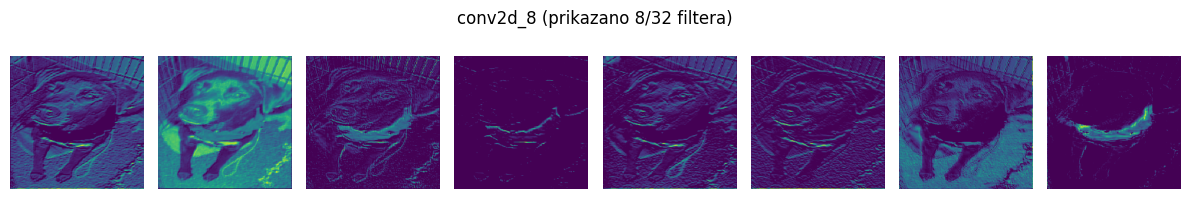

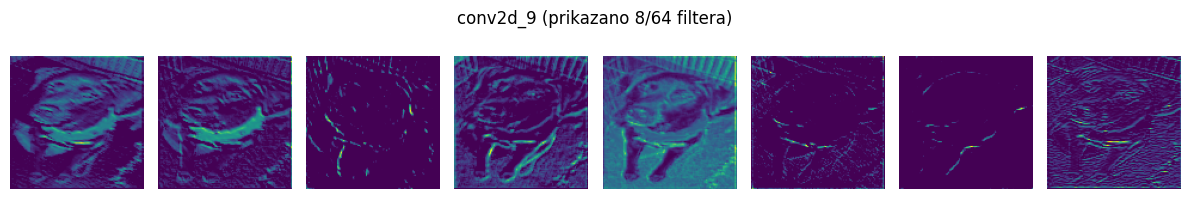

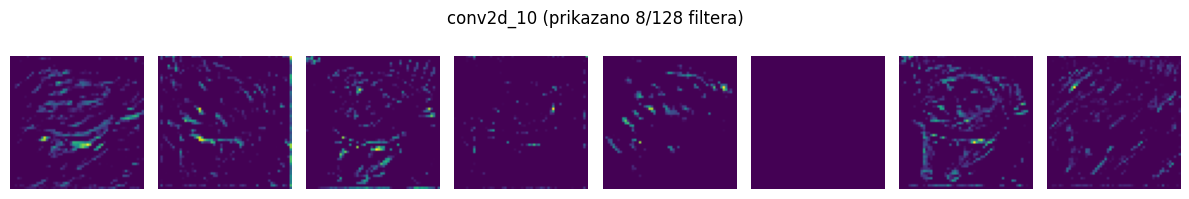

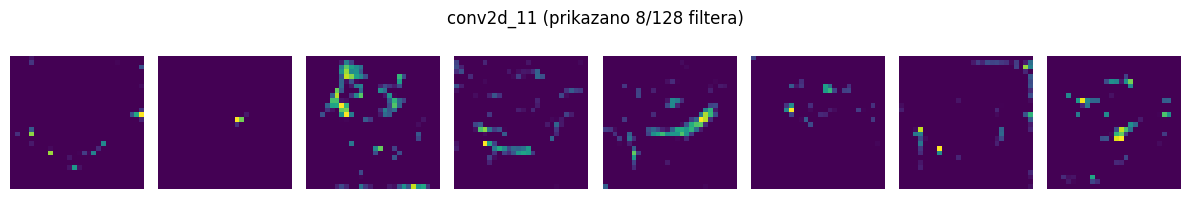

In [ ]:
activations = activation_model.predict(img_batch)


def plot_activations(activations, layer_names, n_filters=8):
    # prikazujemo samo prvih n_filters po sloju (slojevi imaju 32-128 filtera) -
    # dovoljno da se vidi obrazac, bez ogromnog nepreglednog prikaza
    for layer_name, activation in zip(layer_names, activations):
        n_features = activation.shape[-1]
        n_show = min(n_filters, n_features)

        fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.5, 2))
        fig.suptitle(f"{layer_name} (prikazano {n_show}/{n_features} filtera)")

        for i in range(n_show):
            axes[i].imshow(activation[0, :, :, i], cmap="viridis")
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()


plot_activations(activations, conv_layer_names, n_filters=8)

## 5. Primer: mačka

Isti postupak, druga klasa - radi poređenja da li se slični (opšti) obrasci aktiviraju na sličan način kod obe klase, posebno u ranim slojevima.


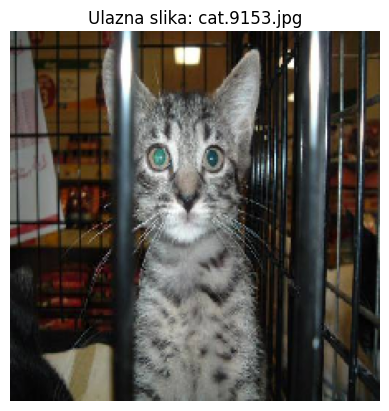

In [ ]:
cat_test_df = split_df[(split_df["split"] == "test") & (split_df["label"] == "cat")]

cat_filename = cat_test_df.iloc[0]["filename"]
cat_path = os.path.join(DATASET_DIR, cat_filename)

cat_img = tf.keras.utils.load_img(cat_path, target_size=(224, 224))
cat_img_array = tf.keras.utils.img_to_array(cat_img) / 255.0
cat_img_batch = np.expand_dims(cat_img_array, axis=0)

plt.imshow(cat_img_array)
plt.title(f"Ulazna slika: {cat_filename}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


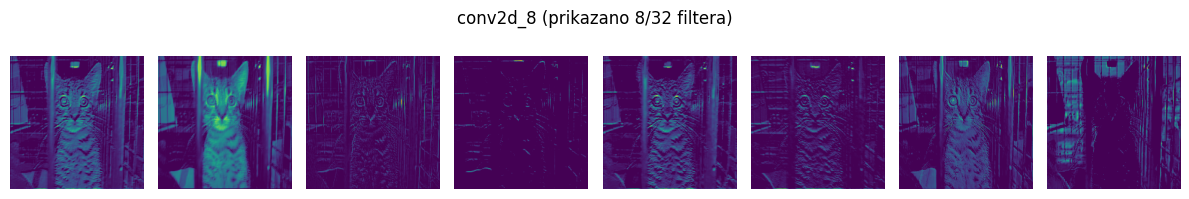

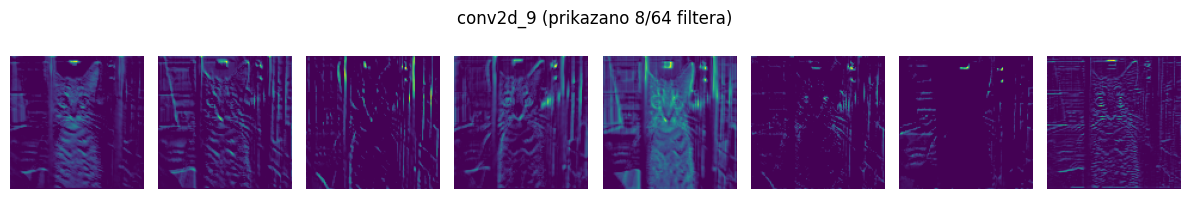

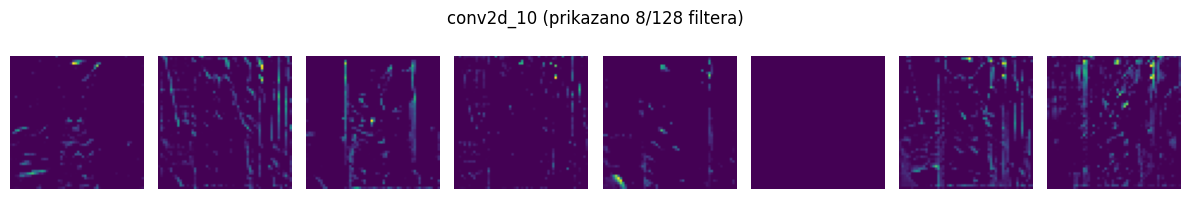

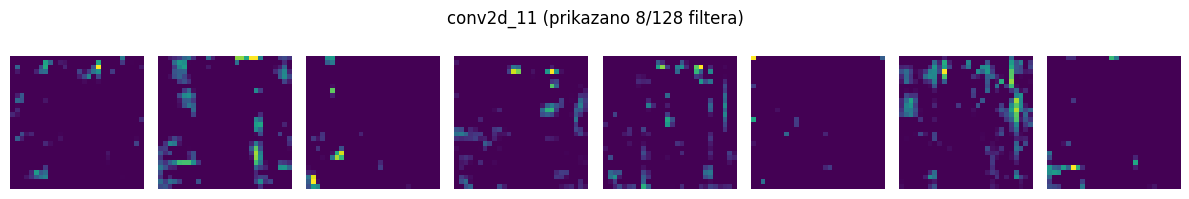

In [ ]:
cat_activations = activation_model.predict(cat_img_batch)
plot_activations(cat_activations, conv_layer_names, n_filters=8)

## 6. Kvantifikacija retkosti (sparsity) po sloju

Umesto da se oslonimo samo na vizuelni utisak "sve više praznih filtera sa dubinom", računamo tačan procenat neaktivnih (nula) vrednosti po sloju, za obe slike, i prikazujemo kao grafikon.


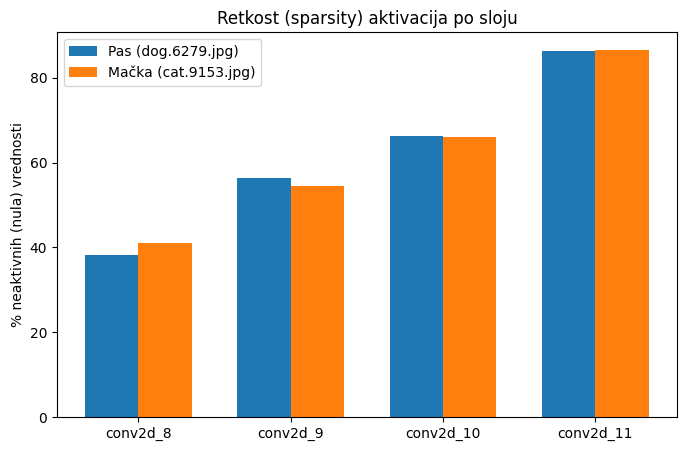

In [ ]:
def compute_sparsity(activations, layer_names):
    sparsity_per_layer = []
    for layer_name, activation in zip(layer_names, activations):
        # activation == 0 pravi niz True/False (da li je vrednost tacno nula -
        # ReLU aktivacija proizvodi tačne nule za negativne ulaze)
        # np.mean nad tim daje udeo nula (True=1, False=0, pa prosek = procenat)
        zero_fraction = np.mean(activation == 0)
        sparsity_per_layer.append(zero_fraction * 100)
    return sparsity_per_layer


dog_sparsity = compute_sparsity(activations, conv_layer_names)
cat_sparsity = compute_sparsity(cat_activations, conv_layer_names)

x = np.arange(len(conv_layer_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, dog_sparsity, width, label="Pas (dog.6279.jpg)")
plt.bar(x + width/2, cat_sparsity, width, label="Mačka (cat.9153.jpg)")
plt.xticks(x, conv_layer_names)
plt.ylabel("% neaktivnih (nula) vrednosti")
plt.title("Retkost (sparsity) aktivacija po sloju")
plt.legend()
plt.show()

## 7. Primer pogrešno klasifikovane slike

Baseline model greši na ~10% test skupa (`02_baseline_cnn.ipynb`- matrica konfuzije). Uzimamo nasumičan uzorak od 100 test slika, nalazimo prvu pogrešno klasifikovanu, i gledamo njene aktivacije - da vidimo da li nešto "odudara" u odnosu na ispravno klasifikovane primere.


Pogrešno klasifikovano: 7 od 100 u ovom uzorku


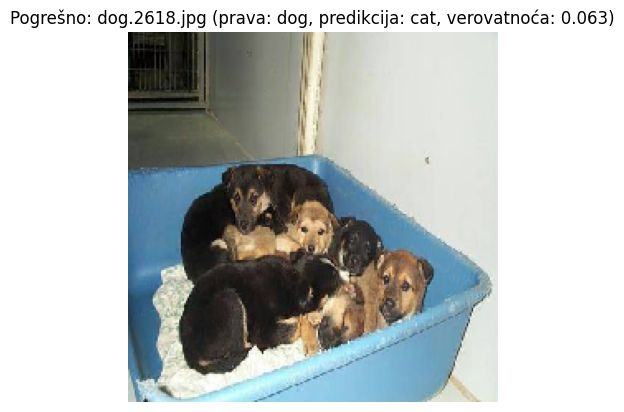

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


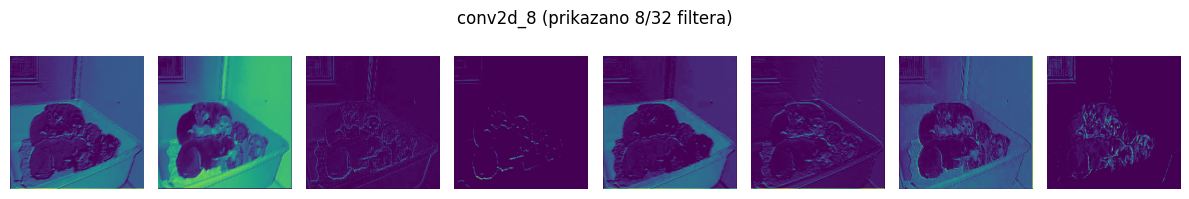

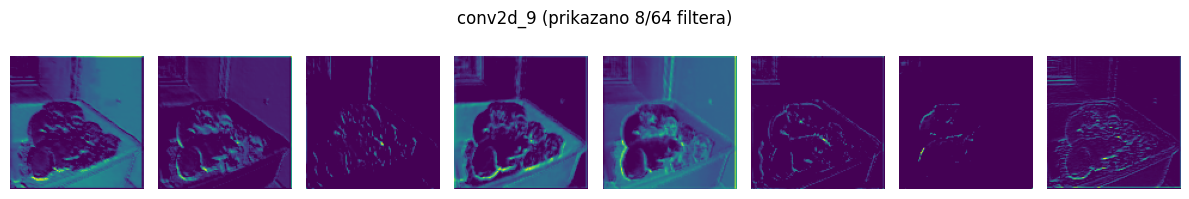

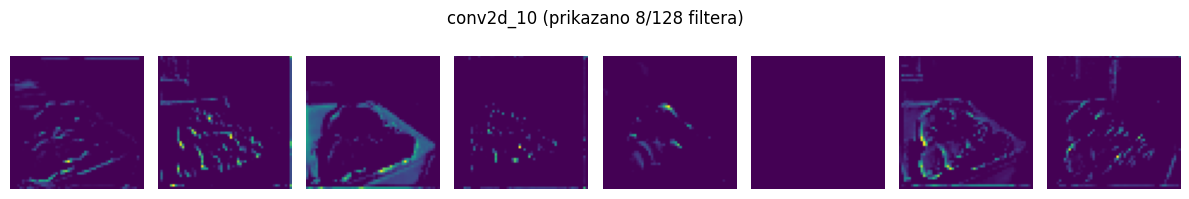

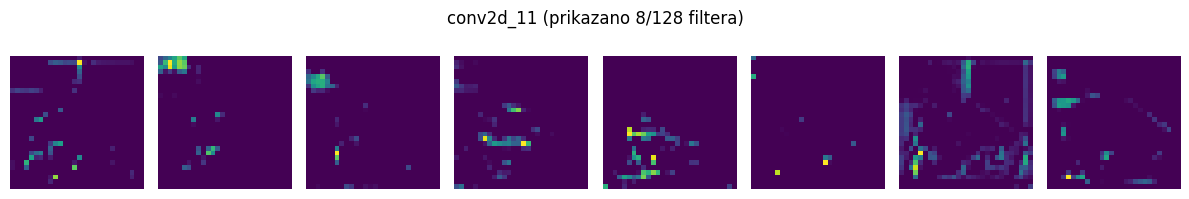

In [ ]:
SEED = 42  # za dosledan nasumičan uzorak

test_df_full = split_df[split_df["split"] == "test"].copy()
test_df_full["filepath"] = test_df_full["filename"].apply(lambda f: os.path.join(DATASET_DIR, f))

label_to_index = {"cat": 0, "dog": 1}
index_to_label = {0: "cat", 1: "dog"}

# uzimamo uzorak od 100 (ne svih 1000) radi brzine - dovoljno da nađemo par pogrešnih,
# pošto baseline model greši na ~10% test slika (02_baseline_cnn.ipynb)
sample_test = test_df_full.sample(n=100, random_state=SEED)


def load_and_preprocess(filepath):
    img = tf.keras.utils.load_img(filepath, target_size=(224, 224))
    return tf.keras.utils.img_to_array(img) / 255.0


X_sample = np.stack([load_and_preprocess(fp) for fp in sample_test["filepath"]])
y_true_sample = sample_test["label"].map(label_to_index).to_numpy()

y_prob_sample = model.predict(X_sample, verbose=0).ravel()
y_pred_sample = (y_prob_sample >= 0.5).astype(int)

wrong_indices = np.where(y_pred_sample != y_true_sample)[0]
print(f"Pogrešno klasifikovano: {len(wrong_indices)} od {len(sample_test)} u ovom uzorku")

# uzimemo privi pogrešan primer iz uzorka
wrong_idx = wrong_indices[0]
wrong_row = sample_test.iloc[wrong_idx]

plt.imshow(X_sample[wrong_idx])
plt.title(f"Pogrešno: {wrong_row['filename']} (prava: {wrong_row['label']}, "
          f"predikcija: {index_to_label[y_pred_sample[wrong_idx]]}, "
          f"verovatnoća: {y_prob_sample[wrong_idx]:.3f})")
plt.axis("off")
plt.show()

wrong_activations = activation_model.predict(np.expand_dims(X_sample[wrong_idx], axis=0))
plot_activations(wrong_activations, conv_layer_names, n_filters=8)

## 8. Naučeni filteri (težine) prvog sloja

Drugačija tehnika od prethodnih - umesto "šta se desi kad slika prođe kroz filter" (aktivacija), gledamo same naučene težine filtera (šta filter "traži"). Moguće samo za prvi sloj, jer jedino njegov kernel ima 3 ulazna kanala (R,G,B) koji se mogu direktno prikazati kao boja.


Oblik težina: (3, 3, 3, 32)


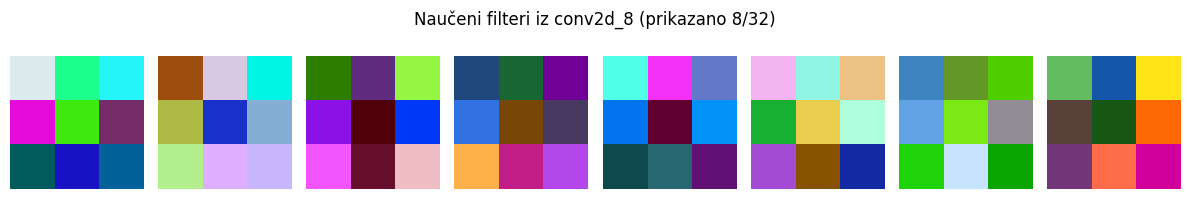

In [ ]:
# za razliku od svega pre - ovde ne gledamo šta se desi kad slika prođe kroz filter
# (aktivacija), nego same naucene tezine filtera (šta filter "traži"). Radimo ovo
# za prvi sloj: njegov kernel ima oblik (3, 3, 3, 32) - poslednja "3" su ulazni
# kanali (R, G, B), pa svaki 3x3 kernel možemo direktno prikazati kao mini RGB sliku.
# Dublji slojevi imaju kernele sa 32/64/128 ulaznih kanala - ne mogu se prikazati kao obična slika.
first_conv_layer = model.get_layer(conv_layer_names[0])
weights, biases = first_conv_layer.get_weights()
print("Oblik težina:", weights.shape)

n_filters_show = 8
fig, axes = plt.subplots(1, n_filters_show, figsize=(n_filters_show * 1.5, 2))
fig.suptitle(f"Naučeni filteri iz {conv_layer_names[0]} (prikazano {n_filters_show}/{weights.shape[-1]})")

for i in range(n_filters_show):
    kernel = weights[:, :, :, i]
    # težine mogu biti bilo koji broj (pozitivan/negativan) - normalizujemo u [0,1] za prikaz boja
    kernel_normalized = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)
    axes[i].imshow(kernel_normalized)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Zaključak

Vizualizacija intermediate layer activations baseline (VGG-6) modela potvrdila je nekoliko obrazaca opisanih u referentnom radu (Lin, 2020), uz par dodatnih zapažanja:

**Rastuća apstraktnost sa dubinom**: prvi konvolucioni sloj (`conv2d_8`) ponaša se kao skup detektora ivica -ulazna slika ostaje jasno prepoznatljiva. Kako se ide dublje (`conv2d_9` → `conv2d_10` → `conv2d_11`), aktivacije postaju sve apstraktnije i sve manje vizuelno prepoznatljive.

**Rastuća retkost (sparsity)**: procenat neaktivnih (nula) vrednosti raste sa dubinom, sa ~38-41% u prvom sloju do ~86-87% u poslednjem, gotovo identično za obe klase (opšte svojstvo mreže, ne specifično za cat/dog).

**"Mrtav" filter**: isti filter (6. po redu prikaza u `conv2d_10`) je potpuno neaktivan kod sve tri testirane slike (pas, mačka, i pogrešno klasifikovana slika) — verovatno tzv. dead ReLU: filter čije težine tokom treninga "zaglave" tako da uvek proizvodi negativnu vrednost pre aktivacije, pa posle ReLU-a uvek ispadne nula, bez obzira na ulaz.

**Analiza pogrešne klasifikacije**: model je pogrešno klasifikovao `dog.2618.jpg` (šest štenaca zajedno u plavoj kadi) kao mačku, sa svega 6.3% verovatnoće za tačnu klasu — vrlo samouverena greška. Slika je neobična u odnosu na tipične trening primere (više životinja odjednom, neuobičajen ugao, kontejner koji zauzima veliki deo kadra), što je verovatan uzrok greške.

**Naučeni filteri prvog sloja**: liče na detektore boje/kontrasta (šarene, blokovske šeme) pre nego na klasične crno-bele detektore ivica, u skladu sa tim da je model treniran od nule na relativno malom skupu podataka, za razliku od mreža treniranih na mnogo većim skupovima (npr. ImageNet).
